In [86]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
df = pd.read_csv("car data.csv")

In [3]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


### Data Cleaning


In [5]:
df.shape

(301, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [8]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
296    False
297    False
298    False
299    False
300    False
Length: 301, dtype: bool

In [9]:
df[df.duplicated(keep=False)]

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
15,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(299, 9)

### EDA

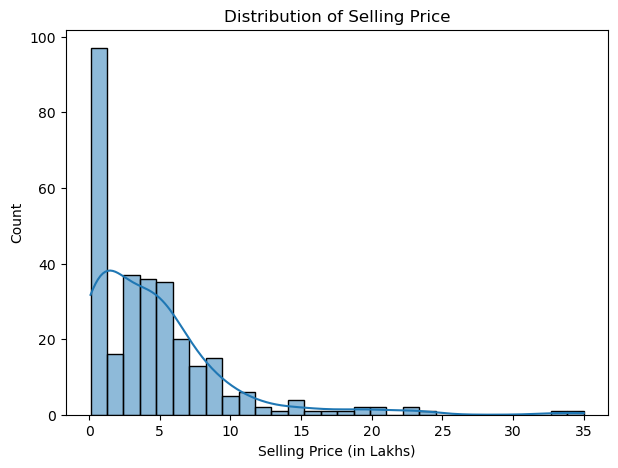

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.histplot(df["Selling_Price"], bins=30, kde=True)
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (in Lakhs)")
plt.show()

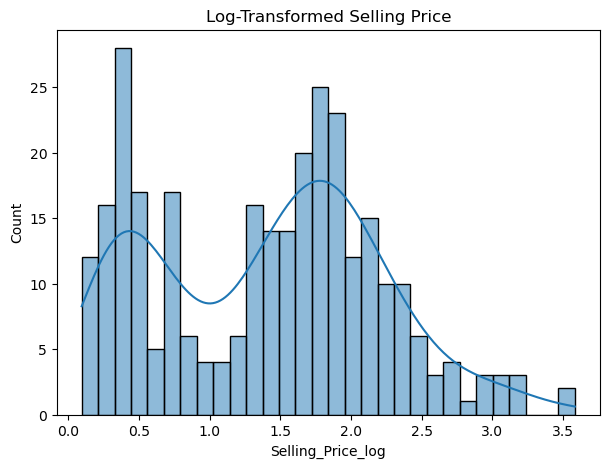

In [14]:
import numpy as np

df["Selling_Price_log"] = np.log1p(df["Selling_Price"])

plt.figure(figsize=(7,5))
sns.histplot(df["Selling_Price_log"], bins=30, kde=True)
plt.title("Log-Transformed Selling Price")
plt.show()

## Brand Goodwill

In [16]:
df["Car_Name"].unique()

array(['ritz', 'sx4', 'ciaz', 'wagon r', 'swift', 'vitara brezza',
       's cross', 'alto 800', 'ertiga', 'dzire', 'alto k10', 'ignis',
       '800', 'baleno', 'omni', 'fortuner', 'innova', 'corolla altis',
       'etios cross', 'etios g', 'etios liva', 'corolla', 'etios gd',
       'camry', 'land cruiser', 'Royal Enfield Thunder 500',
       'UM Renegade Mojave', 'KTM RC200', 'Bajaj Dominar 400',
       'Royal Enfield Classic 350', 'KTM RC390', 'Hyosung GT250R',
       'Royal Enfield Thunder 350', 'KTM 390 Duke ',
       'Mahindra Mojo XT300', 'Bajaj Pulsar RS200',
       'Royal Enfield Bullet 350', 'Royal Enfield Classic 500',
       'Bajaj Avenger 220', 'Bajaj Avenger 150', 'Honda CB Hornet 160R',
       'Yamaha FZ S V 2.0', 'Yamaha FZ 16', 'TVS Apache RTR 160',
       'Bajaj Pulsar 150', 'Honda CBR 150', 'Hero Extreme',
       'Bajaj Avenger 220 dtsi', 'Bajaj Avenger 150 street',
       'Yamaha FZ  v 2.0', 'Bajaj Pulsar  NS 200', 'Bajaj Pulsar 220 F',
       'TVS Apache RTR 180', 

In [31]:
# filtering out bikes

bike_keywords = [
    "Royal Enfield", "Bajaj", "KTM", "Hero", "TVS", "Yamaha",
    "Honda CB", "Honda CBR", "Honda Activa", "Honda Dream", "Honda Karizma",
    "Hyosung", "UM Renegade", "Mahindra Mojo", "Suzuki Access", "Activa"
]

pattern = "|".join(bike_keywords)
is_bike = df["Car_Name"].str.contains(pattern, case=False, na=False)


In [33]:
df = df[~is_bike].reset_index(drop=True)
print(df.shape)
df["Car_Name"].unique()

(198, 11)


array(['ritz', 'sx4', 'ciaz', 'wagon r', 'swift', 'vitara brezza',
       's cross', 'alto 800', 'ertiga', 'dzire', 'alto k10', 'ignis',
       '800', 'baleno', 'omni', 'fortuner', 'innova', 'corolla altis',
       'etios cross', 'etios g', 'etios liva', 'corolla', 'etios gd',
       'camry', 'land cruiser', 'i20', 'grand i10', 'i10', 'eon', 'xcent',
       'elantra', 'creta', 'verna', 'city', 'brio', 'amaze', 'jazz'],
      dtype=object)

In [34]:
# turning these model names into actual brand names

brand_map = {
    "ritz": "Maruti Suzuki", "sx4": "Maruti Suzuki", "ciaz": "Maruti Suzuki",
    "wagon r": "Maruti Suzuki", "swift": "Maruti Suzuki", "vitara brezza": "Maruti Suzuki",
    "s cross": "Maruti Suzuki", "alto 800": "Maruti Suzuki", "ertiga": "Maruti Suzuki",
    "dzire": "Maruti Suzuki", "alto k10": "Maruti Suzuki", "ignis": "Maruti Suzuki",
    "800": "Maruti Suzuki", "baleno": "Maruti Suzuki", "omni": "Maruti Suzuki",
    "eon": "Hyundai", "xcent": "Hyundai", "elantra": "Hyundai",
    "creta": "Hyundai", "verna": "Hyundai", "i20": "Hyundai",
    "grand i10": "Hyundai", "i10": "Hyundai",
    "fortuner": "Toyota", "innova": "Toyota", "corolla altis": "Toyota",
    "etios cross": "Toyota", "etios g": "Toyota", "etios liva": "Toyota",
    "corolla": "Toyota", "etios gd": "Toyota", "camry": "Toyota", "land cruiser": "Toyota",
    "city": "Honda", "brio": "Honda", "amaze": "Honda", "jazz": "Honda",
}

df["brand"] = df["Car_Name"].map(brand_map)


In [35]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner',
       'Selling_Price_log', 'brand'],
      dtype='object')

In [39]:
print(df["brand"].isnull().sum(), "unmapped rows")
df[df["brand"].isnull()]["Car_Name"].unique()

0 unmapped rows


array([], dtype=object)

In [41]:
print("Total unique car models remaining:", df["Car_Name"].nunique())
print(df["brand"].value_counts())

Total unique car models remaining: 37
brand
Hyundai          50
Honda            50
Maruti Suzuki    49
Toyota           49
Name: count, dtype: int64


## Brand Goodwill

In [47]:
goodwill_map = {
    "Maruti Suzuki": 6.5,
    "Hyundai": 7.0,
    "Honda": 7.8,
    "Toyota": 8.5,
}

df["brand_goodwill"] = df["brand"].map(goodwill_map)

df[["brand", "brand_goodwill"]].drop_duplicates()

,brand,brand_goodwill
0,Maruti Suzuki,6.5
49,Toyota,8.5
98,Hyundai,7.0
148,Honda,7.8


## Horsepower

In [52]:
horsepower_map = {
    # Maruti Suzuki
    "ritz": 67, "sx4": 103, "ciaz": 91, "wagon r": 67, "swift": 83,
    "vitara brezza": 89, "s cross": 89, "alto 800": 47, "ertiga": 91,
    "dzire": 83, "alto k10": 67, "ignis": 83, "800": 37, "baleno": 83, "omni": 35,

    # Hyundai
    "eon": 55, "xcent": 82, "elantra": 152, "creta": 126, "verna": 113,
    "i20": 83, "grand i10": 82, "i10": 68,

    # Toyota
    "fortuner": 168, "innova": 132, "corolla altis": 138, "etios cross": 79,
    "etios g": 79, "etios liva": 79, "corolla": 138, "etios gd": 67,
    "camry": 176, "land cruiser": 235,

    # Honda
    "city": 117, "brio": 87, "amaze": 87, "jazz": 87,
}

df["horsepower"] = df["Car_Name"].map(horsepower_map)

print(df["horsepower"].isnull().sum(), "unmapped rows")
df[["Car_Name", "brand", "horsepower"]].drop_duplicates().sort_values("horsepower", ascending=False)

0 unmapped rows


,Car_Name,brand,horsepower
85,land cruiser,Toyota,235
84,camry,Toyota,176
49,fortuner,Toyota,168
108,elantra,Hyundai,152
76,corolla,Toyota,138
54,corolla altis,Toyota,138
51,innova,Toyota,132
109,creta,Hyundai,126
148,city,Honda,117
112,verna,Hyundai,113


## Mileage

In [55]:
def estimate_mileage(row):
    base = 22 - (row["horsepower"] / 25)   # bigger engines -> lower mileage
    if row["Fuel_Type"] == "Diesel":
        base += 3   # diesel engines are generally more fuel-efficient
    elif row["Fuel_Type"] == "CNG":
        base += 5   # CNG typically gives higher effective mileage
    return round(max(base, 8), 1)   # floor at 8 kmpl, unrealistic to go lower

df["mileage_kmpl"] = df.apply(estimate_mileage, axis=1)

df[["Car_Name", "horsepower", "Fuel_Type", "mileage_kmpl"]].head(10)

,Car_Name,horsepower,Fuel_Type,mileage_kmpl
0,ritz,67,Petrol,19.3
1,sx4,103,Diesel,20.9
2,ciaz,91,Petrol,18.4
3,wagon r,67,Petrol,19.3
4,swift,83,Diesel,21.7
5,vitara brezza,89,Diesel,21.4
6,ciaz,91,Petrol,18.4
7,s cross,89,Diesel,21.4
8,ciaz,91,Diesel,21.4
9,ciaz,91,Diesel,21.4


In [68]:
df["car_age"] = 2026 - df["Year"]

## Regression Models

In [70]:
feature_cols = [
    "brand", "car_age", "Present_Price", "Driven_kms",
    "Fuel_Type", "Selling_type", "Transmission", "Owner",
    "brand_goodwill", "horsepower", "mileage_kmpl"
]


In [71]:
X = df[feature_cols]
y = df["Selling_Price"]

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [84]:
print(X_train.shape, X_test.shape)

(158, 11) (40, 11)


In [88]:
numeric_features = ["car_age", "Present_Price", "Driven_kms", "Owner",
                     "brand_goodwill", "horsepower", "mileage_kmpl"]
categorical_features = ["brand", "Fuel_Type", "Selling_type", "Transmission"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

### 1. LinearRegression

In [90]:
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['car_age', 'Present_Price',
                                                   'Driven_kms', 'Owner',
                                                   'brand_goodwill',
                                                   'horsepower',
                                                   'mileage_kmpl']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand', 'Fuel_Type',
                                                   'Selling_type',
                                                   'Transmission'])])),
                ('regressor', LinearRegression())])

In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f} lakhs")
print(f"RMSE: {rmse:.2f} lakhs")
print(f"R2:   {r2:.4f}")

MAE:  1.50 lakhs
RMSE: 3.24 lakhs
R2:   0.6896


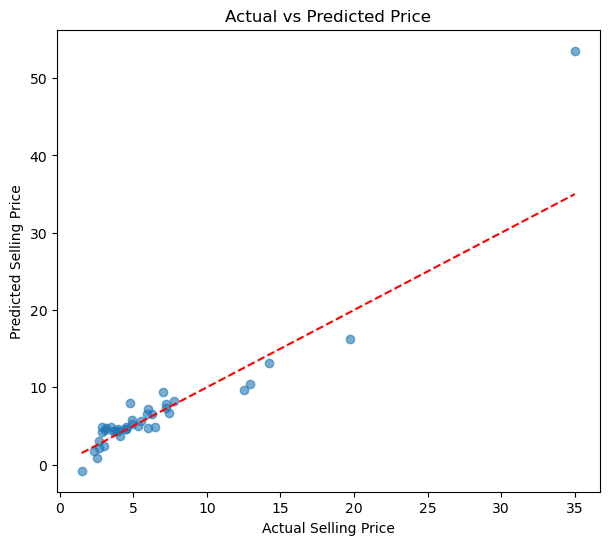

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Price")
plt.show()

### 2. RandomForestRegressor

In [96]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest — MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f}, R2: {rf_r2:.4f}")

Random Forest — MAE: 0.96, RMSE: 2.54, R2: 0.8094


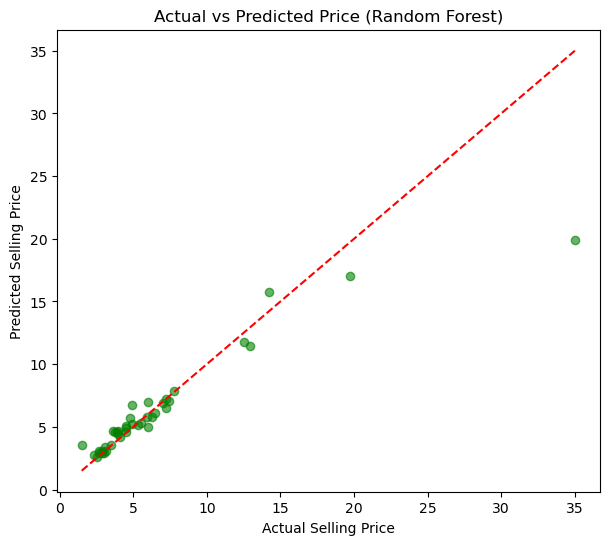

In [98]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, rf_pred, alpha=0.6, color="green")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Price (Random Forest)")
plt.show()

### Model Evaluation

In [106]:
lr_pred = model.predict(X_test)
rf_pred = rf_model.predict(X_test) 

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

results = results.round(3)
print(results)

               Model    MAE   RMSE  R2 Score
0  Linear Regression  1.501  3.236     0.690
1      Random Forest  0.959  2.536     0.809


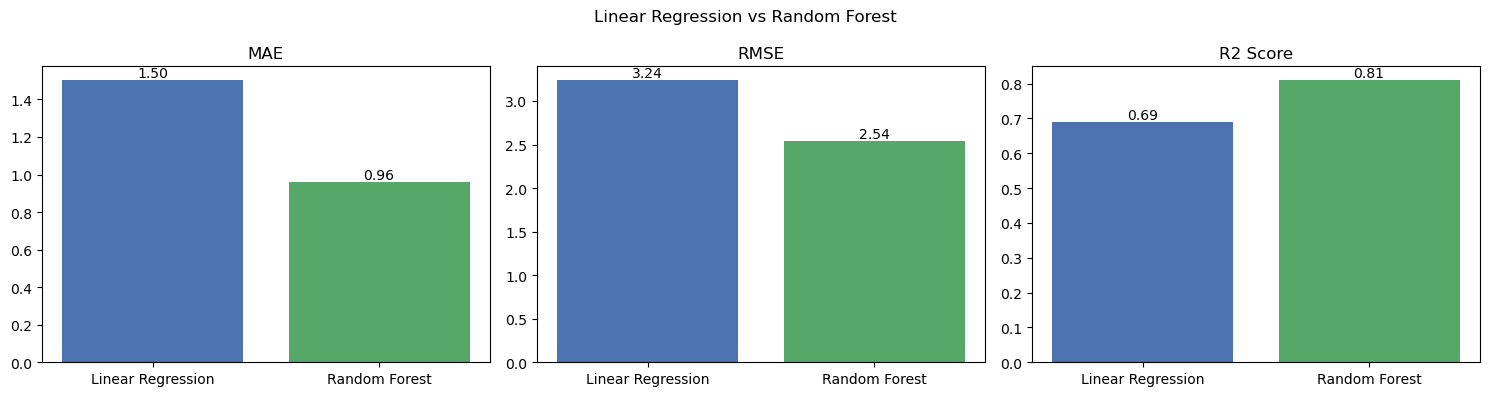

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = ["MAE", "RMSE", "R2 Score"]
colors = ["#4C72B0", "#55A868"]

for ax, metric in zip(axes, metrics):
    ax.bar(results["Model"], results[metric], color=colors)
    ax.set_title(metric)
    for i, v in enumerate(results[metric]):
        ax.text(i, v, f"{v:.2f}", ha="center", va="bottom")

plt.suptitle("Linear Regression vs Random Forest")
plt.tight_layout()
plt.show()